# Optimization Benchmark given different Perturbation to the Original Field
Ported from MATLAB: spectral_main.m + 6 helper .m files.

All operations are 2D spectral (surface only).
Uses JAX for JIT compilation, GPU acceleration, and auto-differentiation.

In [25]:
# Packages

import jax
# Enable 64-bit
jax.config.update("jax_enable_x64", True)
import jax.numpy as jnp
from jax import jit
import jaxopt
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import os
import time
import tkinter as tk
from tkinter import filedialog
import scipy.io as sio
import sys
import dill
import inspect

# For fourier transform
from numpy.fft import rfft2, irfft2

# Input subfiles
%reload_ext autoreload
%autoreload 2

sys.path.insert(0, os.path.join(os.path.dirname(os.path.abspath("__file__")), '..'))
from physics_functions import calculate_surface_u, forward_ssh, vorticity_term
from cost_functions import cost_function_fmin
from ssh_setup import ssh_setup


In [26]:
# # Reload the data
# import dill
# import tkinter as tk
# from tkinter import filedialog
# import numpy as np

# root = tk.Tk(); root.withdraw(); root.attributes("-topmost", True)
# pkl_path = filedialog.askopenfilename(
#     title="Select a workspace .pkl file to load",
#     filetypes=[("Pickle files", "*.pkl"), ("All files", "*.*")],
# )
# root.destroy()

# if not pkl_path:
#     print("No file selected.")
# else:
#     with open(pkl_path, 'rb') as f:
#         ws = dill.load(f)
#     print(f"Loaded: {pkl_path}\n")

#     def describe(value):
#         """Return a short string describing the type/shape of a value."""
#         if isinstance(value, np.ndarray):
#             return f"ndarray  shape={value.shape}  dtype={value.dtype}"
#         if hasattr(value, 'shape') and hasattr(value, 'dtype'):  # jax arrays, etc.
#             return f"{type(value).__name__}  shape={tuple(value.shape)}  dtype={value.dtype}"
#         if isinstance(value, dict):
#             return f"dict  (len={len(value)})"
#         if isinstance(value, (list, tuple)):
#             return f"{type(value).__name__}  (len={len(value)})"
#         if isinstance(value, (int, float, complex, bool, str)):
#             return f"{type(value).__name__} = {value!r}"
#         return type(value).__name__

#     print(f"Top-level keys ({len(ws)}):")
#     print("-" * 72)
#     for k, v in ws.items():
#         print(f"  {k:<22}  {describe(v)}")

#     # Drill one level into dicts (cases, benchmark_results, phi0_s_optimals, ...)
#     print("\nNested structure (one level deep):")
#     print("-" * 72)
#     for k, v in ws.items():
#         if isinstance(v, dict) and len(v) > 0:
#             print(f"\n  {k}:")
#             for sub_k, sub_v in v.items():
#                 if isinstance(sub_v, tuple):
#                     inner = ", ".join(describe(x) for x in sub_v)
#                     print(f"    {sub_k:<22}  tuple({inner})")
#                 elif isinstance(sub_v, dict):
#                     inner_keys = ", ".join(sub_v.keys())
#                     print(f"    {sub_k:<22}  dict  keys=[{inner_keys}]")
#                 else:
#                     print(f"    {sub_k:<22}  {describe(sub_v)}")

#     # Inject into globals so the rest of the notebook can use the loaded variables
#     globals().update(ws)
#     print("\nAll keys injected into globals().")

# Input Field

In [27]:
# Input filed
import sys

print("Select sqgp1_for_thomas.mat ... Cancel to use the default path.")
root = tk.Tk()
root.withdraw()
root.attributes("-topmost", True)
file_path = filedialog.askopenfilename(
    title="Select an SQG+1 .mat file (with psi0n, p1n, Ro)",
    filetypes=[("MATLAB Data Files", "*.mat"), ("All Files", "*.*")],
)
root.destroy()

if not file_path:
    file_path = os.path.join(os.path.dirname(os.path.abspath("__file__")),
                             "data", "sqgp1_for_thomas.mat")
    print(f"No file selected, using default: {file_path}")

mat_contents = sio.loadmat(file_path)
print(f"Loaded: {file_path}")
print(f"Keys:   {[k for k in mat_contents.keys() if not k.startswith('__')]}")

Select sqgp1_for_thomas.mat ... Cancel to use the default path.
Loaded: H:/.shortcut-targets-by-id/1foIkM9fGt2koyZrezcuvdD8lVqZY0fob/ThomasLi_SQGp1_Recon_Project/qg_plus1/data_0515_lp.mat
Keys:   ['Ro_sys', 'p1', 'psi0', 'psi0_lp', 'u1', 'v1', 'zeta0', 'zeta1', 'zeta1_lp']


# Store Field

In [ ]:

## Store the field
# Required fields
psi0n = jnp.asarray(mat_contents["psi0"], dtype=jnp.float64)
psi0n_lp = jnp.asarray(mat_contents["psi0_lp"], dtype=jnp.float64)
p1n   = jnp.asarray(mat_contents["p1"],   dtype=jnp.float64)
Ro_mat = float(mat_contents["Ro_sys"].squeeze())

# Override the system parameters with the value used in the simulation
Ro_sys  = Ro_mat
print(f"  Ro from file -> Ro_sys = {Ro_sys}")

Nx, Ny = psi0n.shape
print(f"Grid size adjusted automatically to Nx={Nx}, Ny={Ny}.")
data_name = os.path.splitext(os.path.basename(file_path))[0]

# Auxiliary fields — kept for diagnostics / plotting
# b_s    = jnp.asarray(mat_contents["b_lp"],     dtype=jnp.float64)
zeta0n = jnp.asarray(mat_contents["zeta0"], dtype=jnp.float64)
zeta1n = jnp.asarray(mat_contents["zeta1"], dtype=jnp.float64)
zeta1n_lp =  jnp.asarray(mat_contents["zeta1_lp"], dtype=jnp.float64)


  Ro from file -> Ro_sys = epsilon = 0.05
Grid size adjusted automatically to Nx=512, Ny=512.


# Grid Setup

In [29]:
# Grid Setup
Lx = 2.0 * jnp.pi
Ly = 2.0 * jnp.pi
Bu = 1.0
dx = Lx / Nx
dy = Ly / Ny
x = jnp.arange(Nx) * dx
y = jnp.arange(Ny) * dy
X, Y = jnp.meshgrid(x, y, indexing='ij')

# Spectral grid
dk = 1.0
dl = 1.0
k_zonal     = jnp.concatenate([jnp.arange(Nx//2), jnp.arange(-Nx//2, 0)]) * dk
l_meridional = jnp.concatenate([jnp.arange(Ny//2), jnp.arange(-Ny//2, 0)]) * dl
k_zonal      = k_zonal.at[Nx//2].set(0.0)      # kill Nyquist
l_meridional = l_meridional.at[Ny//2].set(0.0)
kx, ky = jnp.meshgrid(k_zonal, l_meridional, indexing='ij')

# The square of K
K2 = kx**2 + ky**2
K = jnp.sqrt(K2)

# Safe inverses (avoid division by zero at k=0)
inv_K = jnp.where(K > 0, 1.0 / K, 0.0)
inv_K2 = jnp.where(K2 > 0, 1.0 / K2, 0.0)

# This is for taking derivative in $z$ direction.
mu = jnp.sqrt(Bu) * K
inv_mu = jnp.where(mu > 0, 1.0 / mu, 0.0)


# Key Parameters

In [37]:
# Controling the scale of correction field
print(Ro_sys)

# Control the scale of perturbation
epsilon = 8 * Ro_sys

0.05


# Low Pass Filter 

In [31]:
from lowpass import lowpass
K_lp = 170

# Target Field

Now the Target Surface Sea Height should perhaps be the qg streamfunction adding the ageostrophic correction. That is 

$$ \eta_{tar} = \eta_{qg} + \epsilon \cdot \eta^1 $$

So a forward here is perform to generate the target field


In [ ]:
def dealias_nyquist(field_hat, Nx, Ny):
    field_hat = field_hat.at[Nx // 2, :].set(0.0)
    field_hat = field_hat.at[:, Ny // 2].set(0.0)
    return field_hat


# QG streamfunction (truth) — taken straight from the .mat file
# phi0_s_hat_lp = jnp.fft.fft2(psi0n_lp) # Apply lowpass filter here?
# phi0_s_hat = knp.fft.fft2(psi0n) # no low pass
# phi0_s_hat = dealias_nyquist(phi0_s_hat, Nx, Ny)
# phi0_s     = jnp.real(jnp.fft.ifft2(phi0_s_hat))

# Low pass
ssh_qg_lp     = psi0n_lp
phi0_s_lp = ssh_qg_lp
phi0_hat_lp_ssh = jnp.fft.fft2(phi0_s_lp)

# Target SSH from forward model. 
eta_tar_hat     = forward_ssh(phi0_hat_lp_ssh, kx, ky, mu, inv_mu,
                            K2, inv_K2, Bu, Ro_sys)

# Filter
eta_tar_hat_lp = lowpass(eta_tar_hat, K_lp)

eta_tar_lp = jnp.real(jnp.fft.ifft2(eta_tar_hat_lp))


# Filter Small Scale

Adapt a filter from literature 

\begin{equation}
    \hat{\bar{q}}_\kappa =
    \begin{cases}
        \hat{q}_\kappa, & \kappa < \kappa^c, \\
        \hat{q}_\kappa \cdot e^{-23.6(\kappa - \kappa^c)^4 \Delta x_{\text{lores}}^4}, & \kappa \geq \kappa^c.
    \end{cases}
\end{equation}

Let $\kappa$ denote the wavenumber, $\Delta x_{\text{lores}}$ the grid spacing of the coarse model, and define the cutoff $\kappa^c \equiv 2/3$ of the low-resolution Nyquist frequency.

In [33]:
# # ── Low-pass filter on the input psi0n AND the target eta_tar ──
# # tilde{q}_hat(K) = q_hat(K)                                 if K < kappa_c
# #                  q_hat(K) * exp(-23.6 (K - kappa_c)^4 dx_lores^4)  if K >= kappa_c
# #
# # We filter BOTH the initial guess (psi0n) and the target SSH (eta_tar) so
# # the inversion is solved on a self-consistent low-pass-filtered problem.

# from spectrum_diagnostics import azimuthal_sum

# kappa_c  = 100                    # cutoff wavenumber (current grid Nyquist)
# dx_lores = float(Lx) / float(Nx)    # grid spacing of the (high-res) model

# print(f"  kappa_c  = {kappa_c}")
# print(f"  dx_lores = {dx_lores:.6e}")

# # Build the 2-D filter mask
# exponent  = -23.6 * (K - kappa_c) ** 4 * dx_lores ** 4
# filter_lp = jnp.where(K < kappa_c, 1.0, jnp.exp(exponent))


# def _apply_lp(field_phys):
#     """Forward FFT, multiply by filter, dealias Nyquist, return (phys, hat)."""
#     f_pre_hat = jnp.fft.fft2(field_phys)
#     f_lp_hat  = f_pre_hat * filter_lp
#     f_lp_hat  = dealias_nyquist(f_lp_hat, Nx, Ny)
#     f_lp      = jnp.real(jnp.fft.ifft2(f_lp_hat))
#     return f_pre_hat, f_lp_hat, f_lp


# def _rms(x):
#     return float(jnp.sqrt(jnp.mean(x ** 2)))


# # ── psi0n  →  psi0_lpfilter ──────────────────────────────────────────────
# psi0_raw          = psi0n
# psi0_pre          = psi0n
# psi0_pre_hat, psi0_lpfilter_hat, psi0_lpfilter = _apply_lp(psi0n)


# # ── eta_tar  →  eta_tar_lpfilter ─────────────────────────────────────────
# eta_tar_pre          = eta_tar
# eta_tar_pre_hat, eta_tar_lpfilter_hat, eta_tar_lpfilter = _apply_lp(eta_tar)

# print(f"  rms psi0n    (pre)  = {_rms(psi0_pre):.4e}")
# print(f"  rms psi0n    (post) = {_rms(psi0_lpfilter):.4e}")
# print(f"  rms removed         = {_rms(psi0_pre - psi0_lpfilter):.4e}")
# print(f"  rms eta_tar  (pre)  = {_rms(eta_tar_pre):.4e}")
# print(f"  rms eta_tar  (post) = {_rms(eta_tar_lpfilter):.4e}")
# print(f"  rms removed         = {_rms(eta_tar_pre - eta_tar_lpfilter):.4e}")


# # ── Spectra: before vs after filtering ───────────────────────────────────
# norm = (Nx * Ny) ** 2

# def _radial_psd(field_hat):
#     p2d = jnp.abs(field_hat) ** 2 / norm
#     k_axis, p1d = azimuthal_sum(p2d, K, dk)
#     return k_axis, p1d


# k_axis,  S_psi0_pre  = _radial_psd(psi0_pre_hat)
# _,       S_psi0_post = _radial_psd(psi0_lpfilter_hat)
# _,       S_eta_pre   = _radial_psd(eta_tar_pre_hat)
# _,       S_eta_post  = _radial_psd(eta_tar_lpfilter_hat)

# mask = k_axis > 0
# k_plot_max = Nx // 2

# fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(13, 4.5), constrained_layout=True)

# ax0.loglog(k_axis[mask], S_psi0_pre[mask],  lw=1.4, color="C0",
#            label=r"$\psi_{0,n}$  (pre-filter)")
# ax0.loglog(k_axis[mask], S_psi0_post[mask], lw=1.2, color="C0", ls="--",
#            label=r"$\psi_{0,\mathrm{lp}}$  (post-filter)")
# ax0.axvline(kappa_c, color="k", lw=0.7, ls=":", label=rf"$\kappa_c={kappa_c}$")
# ax0.set_xlabel("wavenumber  $k$")
# ax0.set_ylabel(r"radial PSD  $|\hat{\psi}_0(k)|^2$")
# ax0.set_title("Initial-guess streamfunction spectrum")
# ax0.set_xlim(1, k_plot_max)
# ax0.grid(True, which="both", alpha=0.3)
# ax0.legend(fontsize=9)

# ax1.loglog(k_axis[mask], S_eta_pre[mask],  lw=1.4, color="C3",
#            label=r"$\eta_{tar}$  (pre-filter)")
# ax1.loglog(k_axis[mask], S_eta_post[mask], lw=1.2, color="C3", ls="--",
#            label=r"$\eta_{tar,\mathrm{lp}}$  (post-filter)")
# ax1.axvline(kappa_c, color="k", lw=0.7, ls=":", label=rf"$\kappa_c={kappa_c}$")
# ax1.set_xlabel("wavenumber  $k$")
# ax1.set_ylabel(r"radial PSD  $|\hat{\eta}_{tar}(k)|^2$")
# ax1.set_title("Target SSH spectrum")
# ax1.set_xlim(1, k_plot_max)
# ax1.grid(True, which="both", alpha=0.3)
# ax1.legend(fontsize=9)

# plt.show()


# Build the Observation SSH (no synthetic perturbation)

The .mat file already gives us the true QG streamfunction `psi0n` and the
first-order pressure correction `p1n`, so the "observation" is simply
`eta_obs = psi0n + Ro * p1n`. To stay compatible with the inversion
benchmark below, we wrap it as a single entry in a `cases` dict.

In [34]:
%reload_ext autoreload
%autoreload 2

rng_key = jax.random.PRNGKey(42)
print(epsilon)
print(f"Ro_sys  = {Ro_sys}")
print(f"epsilon = {epsilon}")

from perturbation_setup_v4 import build_all_perturbations, print_rms_table

cases = build_all_perturbations(
    eta_tar_lp, eta_tar_hat_lp, kx, ky, K, K2, inv_K2,
    mu, inv_mu, Bu, epsilon, X, Y, Lx, Ly, rng_key
)

print(f"  max |phi0_s|     = {jnp.max(jnp.abs(phi0_s_lp)):.6f}")
print()

for name, (eta_perturb, eta_obs) in cases.items():
    print(f"[{name}]")
    print(f"  max |perturb|  = {jnp.max(jnp.abs(eta_perturb)):.6f}")
    print(f"  max |eta_obs| = {jnp.max(jnp.abs(eta_obs)):.6f}")
    print(f"  ratio (perturb / phi0_s) = {jnp.max(jnp.abs(eta_perturb)) / jnp.max(jnp.abs(phi0_s_lp)):.4f}")
    print()

0.04000000000000001
Ro_sys  = 0.05
epsilon = 0.04000000000000001
  max |phi0_s|     = 0.303522

[A1_nothing]
  max |perturb|  = 0.000000
  max |eta_obs| = 0.086708
  ratio (perturb / phi0_s) = 0.0000

[E3_swot_aliased]
  max |perturb|  = 0.003122
  max |eta_obs| = 0.087055
  ratio (perturb / phi0_s) = 0.0103



# Pre-Compare

Compare the Vorticity field After the perturbation with true field. 

  rms eta_truth (= psi0 + Ro_sys * p1) = 3.7702e-02
  Ro_sys = 0.05
[A1_nothing]
  rms perturbation       = 0.0000e+00
  rms eta_after (truth+perturb) = 3.7702e-02
  rms ratio perturb/truth = 0.0000%
[E3_swot_aliased]
  rms perturbation       = 6.9900e-04
  rms eta_after (truth+perturb) = 3.7709e-02
  rms ratio perturb/truth = 1.8540%


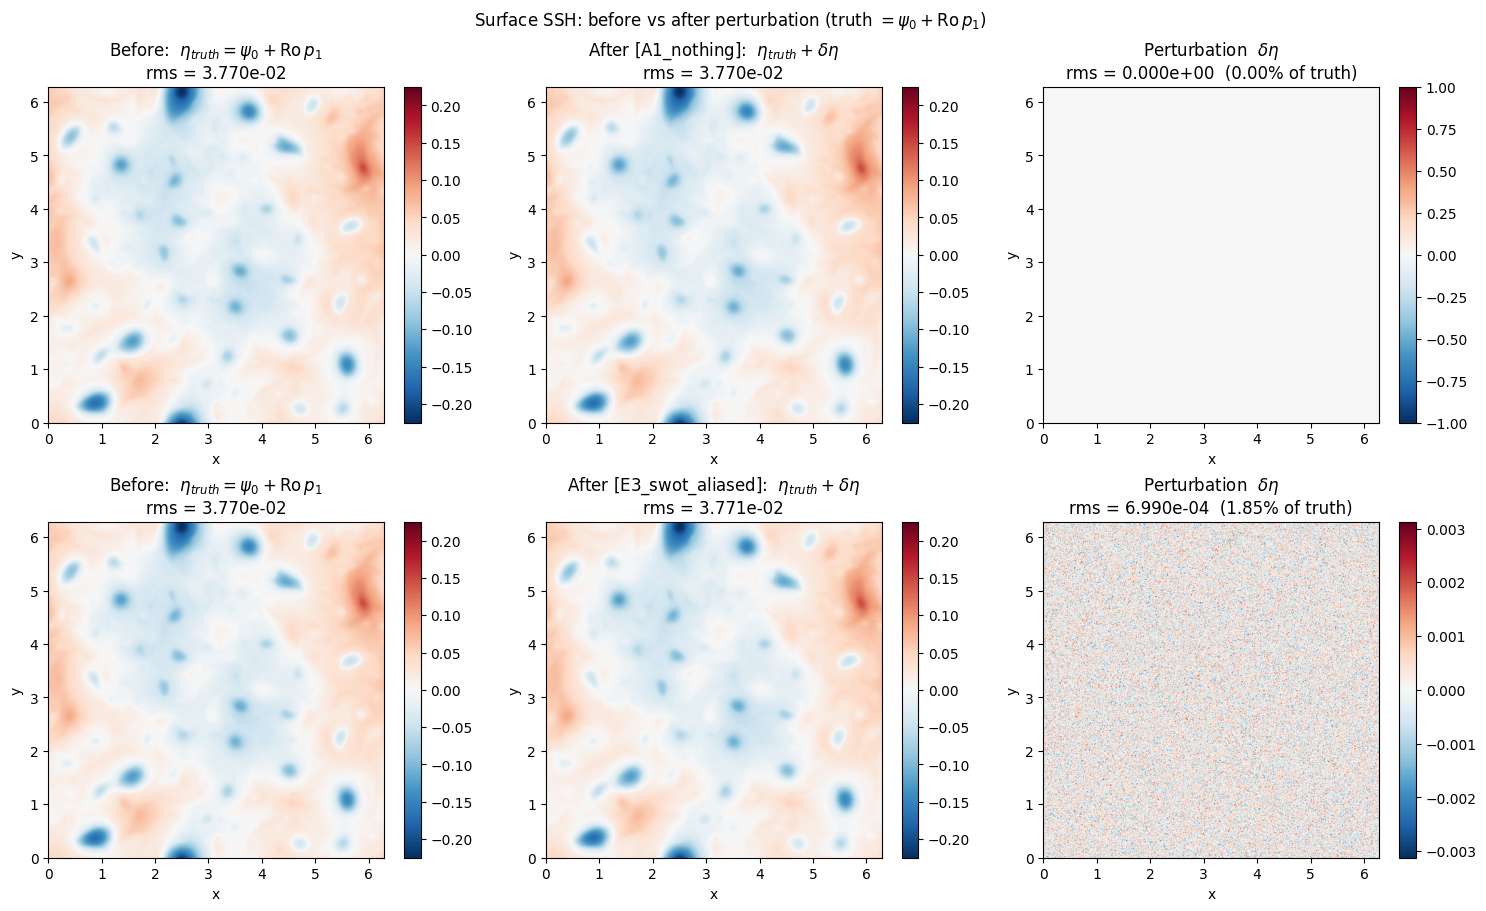

In [36]:
# ── Compare surface SSH: before vs after perturbation ────────────────────
# Truth SSH straight from the .mat fields:   eta_truth = psi0n + Ro_sys * p1n
# "Before" perturbation = eta_truth
# "After"  perturbation = eta_truth + eta_perturb   (one panel-row per case)

def _rms(x):
    return float(jnp.sqrt(jnp.mean(x ** 2)))

eta_truth = psi0n + Ro_sys * p1n
rms_truth = _rms(eta_truth)
print(f"  rms eta_truth (= psi0 + Ro_sys * p1) = {rms_truth:.4e}")
print(f"  Ro_sys = {Ro_sys}")

extent     = [0, float(Lx), 0, float(Ly)]
vmax_field = float(jnp.max(jnp.abs(eta_truth)))

case_names = list(cases.keys())
n_rows     = len(case_names)
fig, axes  = plt.subplots(n_rows, 3, figsize=(15, 4.5 * n_rows),
                          constrained_layout=True, squeeze=False)

for row, name in enumerate(case_names):
    eta_perturb, _ = cases[name]
    eta_after      = eta_truth + eta_perturb

    rms_perturb = _rms(eta_perturb)
    rms_after   = _rms(eta_after)
    rel_perturb = rms_perturb / rms_truth if rms_truth > 0 else float("nan")

    print(f"[{name}]")
    print(f"  rms perturbation       = {rms_perturb:.4e}")
    print(f"  rms eta_after (truth+perturb) = {rms_after:.4e}")
    print(f"  rms ratio perturb/truth = {rel_perturb:.4%}")

    # Symmetric color range for the perturbation panel
    vmax_perturb = float(jnp.max(jnp.abs(eta_perturb)))
    if vmax_perturb == 0.0:
        vmax_perturb = 1.0  # avoid degenerate colorbar for zero-perturbation cases

    im0 = axes[row, 0].imshow(eta_truth, origin="lower", cmap="RdBu_r",
                              vmin=-vmax_field, vmax=vmax_field, extent=extent)
    axes[row, 0].set_title(r"Before:  $\eta_{truth} = \psi_0 + \mathrm{Ro}\,p_1$"
                           + f"\nrms = {rms_truth:.3e}")
    plt.colorbar(im0, ax=axes[row, 0], fraction=0.046)

    im1 = axes[row, 1].imshow(eta_after, origin="lower", cmap="RdBu_r",
                              vmin=-vmax_field, vmax=vmax_field, extent=extent)
    axes[row, 1].set_title(rf"After [{name}]:  $\eta_{{truth}} + \delta\eta$"
                           + f"\nrms = {rms_after:.3e}")
    plt.colorbar(im1, ax=axes[row, 1], fraction=0.046)

    im2 = axes[row, 2].imshow(eta_perturb, origin="lower", cmap="RdBu_r",
                              vmin=-vmax_perturb, vmax=vmax_perturb, extent=extent)
    axes[row, 2].set_title(rf"Perturbation  $\delta\eta$"
                           + f"\nrms = {rms_perturb:.3e}"
                           + f"  ({rel_perturb:.2%} of truth)")
    plt.colorbar(im2, ax=axes[row, 2], fraction=0.046)

    for ax in axes[row]:
        ax.set_xlabel("x"); ax.set_ylabel("y")

fig.suptitle("Surface SSH: before vs after perturbation "
             r"(truth $= \psi_0 + \mathrm{Ro}\,p_1$)", fontsize=12)
plt.show()
plt.close(fig)

# Inversion Part

First setup the initial guess field. The initial guess should be the QG surface streamfunction which is the same as QG surface sea height

In [ ]:
# ── Inversion: GLS loss + LP-projected forward map ──────────────────────
# Two modifications vs the unweighted L2 baseline:
#   (1) forward_ssh now LP-projects phi0_hat at the top, so the unknown is
#       parameterized in the band-limited subspace the observation can
#       constrain. No high-k null-space modes for the optimizer to corrupt.
#   (2) The loss weights modes by 1/S_n(K), with a Lorentzian-style noise
#       model:   S_n(K) = 1 + (K / K_c)^p     (K_c = kappa_c, p = 4)
#       Below K_c: weight ≈ 1 (uniform). Above K_c: weight ~ (K_c/K)^p,
#       progressively damping high-k residual that the data can't constrain.
#
# Setup pulled from cells above:
#   eta_tar_lpfilter = LP{psi0n + Ro_sys * p1n}    ← target SSH (filtered)
#   phi0_s_guess     = psi0_lpfilter               ← LP{psi0n} as init guess
#   filter_lp        =  the spectral LP mask built earlier (kappa_c = 100)

from cost_functions import cost_function_fmin_gls

# Initial guess (band-limited)
phi0_s_guess = psi0_lpfilter

# ── Build the GLS spectral weight  weight = 1 / S_n(K) ────────────────────
gls_p   = 4                          # high-k slope of the noise model
gls_K_c = float(kappa_c)             # match the LP filter cutoff
S_n     = 1.0 + (K / gls_K_c) ** gls_p
weight  = 1.0 / S_n
print(f"  GLS noise model: S_n(K) = 1 + (K/{gls_K_c:.0f})^{gls_p}")
print(f"    weight at K=0       = {float(weight[0,0]):.4f}")
print(f"    weight at K=K_c     = {1.0/(1.0 + 1.0**gls_p):.4f}  (analytic)")
print(f"    weight at K=2 K_c   = {1.0/(1.0 + 2.0**gls_p):.4f}  (analytic)")

# ── Sanity asserts ────────────────────────────────────────────────────────
assert eta_tar_lpfilter.shape == (Nx, Ny), "eta_tar_lpfilter shape mismatch"
assert phi0_s_guess.shape    == (Nx, Ny), "phi0_s_guess shape mismatch"
assert filter_lp.shape       == (Nx, Ny), "filter_lp shape mismatch"
assert weight.shape          == (Nx, Ny), "weight shape mismatch"
assert len(cases) == 1, f"expected exactly one case, got {len(cases)}"
(case_name, (perturb, eta_obs)), = list(cases.items())
assert bool(jnp.allclose(eta_obs, eta_tar_lpfilter)), \
    "cases entry's eta_obs != eta_tar_lpfilter"

print(f"Inversion case: {case_name!r}")
print(f"  rms eta_tar_lpfilter = "
      f"{float(jnp.sqrt(jnp.mean(eta_tar_lpfilter**2))):.4e}")
print(f"  rms phi0_s_guess     = "
      f"{float(jnp.sqrt(jnp.mean(phi0_s_guess**2))):.4e}")

num_iterations   = 20000
loss_threshold   = 1e-3 * epsilon ** 2
grad_threshold   = 1e-2 * epsilon ** 2
log_every        = 1000
stagnation_ratio = 0.9999  # break if loss_new / loss_prev > this over log_every steps
print(f"  loss_threshold  = {loss_threshold:.2e}")
print(f"  grad_threshold  = {grad_threshold:.2e}")

benchmark_results = {}   # {name: {iters, elapsed, final_loss, final_grad, loss_history}}
phi0_s_optimals   = {}   # {name: (Nx, Ny) optimal streamfunction}


@jit
def loss_fn(phi0_flat, target):
    phi0_2d = phi0_flat.reshape(Nx, Ny)
    return cost_function_fmin_gls(
        phi0_2d, kx, ky, mu, inv_mu, Bu, Ro_sys, K2, inv_K2, target,
        weight, filter_lp,
    )

grad_fn = jit(jax.grad(loss_fn))

# Spectral target — the LOW-PASS-FILTERED SSH
target_hat      = jnp.fft.fft2(eta_tar_lpfilter)
phi0_flat_guess = phi0_s_guess.ravel()

print(f"\n{'='*60}")
print(f"  Case: {case_name}   GLS loss + LP-projected forward map")
print(f"{'='*60}")

solver = jaxopt.LBFGS(fun=loss_fn, maxiter=num_iterations, tol=1e-8)
state  = solver.init_state(phi0_flat_guess, target_hat)
params = phi0_flat_guess

# Initial loss / |grad| at iter 0
loss_val = float(loss_fn(params, target_hat))
g_norm   = float(jnp.linalg.norm(grad_fn(params, target_hat)))
print(f"  Iter     0 | Loss = {loss_val:.6e} | |grad| = {g_norm:.6e}  (initial)")

loss_history = []
t0 = time.time()
converged_iter = num_iterations
prev_checkpoint_loss = None

for it in range(num_iterations):
    params, state = solver.update(params, state, target_hat)
    loss_val = float(loss_fn(params, target_hat))
    g_norm   = float(jnp.linalg.norm(grad_fn(params, target_hat)))
    loss_history.append(loss_val)

    if (it + 1) % log_every == 0 or it == 0:
        print(f"  Iter {it+1:5d} | Loss = {loss_val:.6e} | |grad| = {g_norm:.6e}")
        if prev_checkpoint_loss is not None and prev_checkpoint_loss > 0:
            ratio = loss_val / prev_checkpoint_loss
            if ratio > stagnation_ratio:
                print(f"  ** Stagnated at iter {it+1}  "
                      f"(loss ratio = {ratio:.6f} > {stagnation_ratio})")
                converged_iter = it + 1
                break
        prev_checkpoint_loss = loss_val

    if loss_val < loss_threshold:
        print(f"  ** Converged (loss) at iter {it+1}  "
              f"(Loss = {loss_val:.6e}, |grad| = {g_norm:.6e})")
        converged_iter = it + 1
        break

    if g_norm < grad_threshold:
        print(f"  ** Converged (|grad|) at iter {it+1}  "
              f"(Loss = {loss_val:.6e}, |grad| = {g_norm:.6e})")
        converged_iter = it + 1
        break

elapsed = time.time() - t0

# ── LP-project phi0_opt so downstream uses the band-limited recovered field ──
# (forward_ssh internally LP-filters anyway; storing the projected version
#  makes the post-analysis cells consistent without further changes.)
phi0_opt_raw = params.reshape(Nx, Ny)
phi0_opt_hat = jnp.fft.fft2(phi0_opt_raw) * filter_lp
phi0_opt_hat = phi0_opt_hat.at[Nx // 2, :].set(0.0).at[:, Ny // 2].set(0.0)
phi0_opt_lp  = jnp.real(jnp.fft.ifft2(phi0_opt_hat))

phi0_s_optimals[case_name] = phi0_opt_lp
benchmark_results[case_name] = {
    'iters':        converged_iter,
    'elapsed':      elapsed,
    'final_loss':   loss_val,
    'final_grad':   float(jnp.linalg.norm(grad_fn(params, target_hat))),
    'loss_history': loss_history,
    'gls_p':        gls_p,
    'gls_K_c':      gls_K_c,
}

print(f"  Done: {converged_iter} iters, {elapsed:.1f}s, final loss = {loss_val:.4e}")
print(f"  rms phi0_opt (raw)         = "
      f"{float(jnp.sqrt(jnp.mean(phi0_opt_raw**2))):.4e}")
print(f"  rms phi0_opt (LP-projected)= "
      f"{float(jnp.sqrt(jnp.mean(phi0_opt_lp**2))):.4e}")
print("\nInversion complete.")


# Result Analysis

For most of the case, the convergent is really fast. However although the final gradient is near 0, actually the lost function is not. Indicating the SQG+1 model is not capable of reconstructing a surface sea height exactly equals to the perturbed field. This is reasonable since the perturbation we added is not QG. I would compare the SSH_target with the inversed ssh. 

In [ ]:
# ── Compare target SSH vs reconstructions from initial guess and optimum ──
# eta_target = eta_tar_lpfilter = LP(psi0n + Ro_sys * p1n)   (inversion target)
# eta_init   = forward_ssh(phi0_s_guess)   (toy SQG+1 SSH from the INITIAL guess)
# eta_opt    = forward_ssh(phi0_opt)       (toy SQG+1 SSH from the OPTIMIZED phi0)

import os
from tkinter import Tk, filedialog

store_all = False  # set True to save the figure

assert eta_tar_lpfilter.shape == (Nx, Ny), \
    "eta_tar_lpfilter not defined / wrong shape"
assert phi0_s_guess.shape == (Nx, Ny), \
    "phi0_s_guess not defined / wrong shape"
assert len(phi0_s_optimals) == 1, \
    f"expected one optimum, got {len(phi0_s_optimals)}"
case_name, phi0_opt = next(iter(phi0_s_optimals.items()))

# Optional save folder
save_dir = None
if store_all:
    root = Tk(); root.withdraw(); root.attributes("-topmost", True)
    save_dir = filedialog.askdirectory(title="Choose folder to save the figure")
    root.destroy()
    if save_dir:
        os.makedirs(save_dir, exist_ok=True)
        print(f"Saving figure to: {save_dir}")
    else:
        print("No folder selected — figure shown but not saved.")


def _forward_eta(phi_phys):
    phi_hat = jnp.fft.fft2(phi_phys)
    eta_hat = forward_ssh(phi_hat, kx, ky,
                          mu, inv_mu, K2, inv_K2, Bu, Ro_sys)
    return jnp.real(jnp.fft.ifft2(eta_hat))


def _rms(x):
    return float(jnp.sqrt(jnp.mean(x ** 2)))


# Target and the two reconstructions
eta_target  = eta_tar_lpfilter
eta_init    = _forward_eta(phi0_s_guess)
eta_opt     = _forward_eta(phi0_opt)

residual_init = eta_init - eta_target
residual_opt  = eta_opt  - eta_target

rms_target        = _rms(eta_target)
rms_residual_init = _rms(residual_init)
rms_residual_opt  = _rms(residual_opt)
rel_err_init      = (rms_residual_init / rms_target) if rms_target > 0 else float("nan")
rel_err_opt       = (rms_residual_opt  / rms_target) if rms_target > 0 else float("nan")

r = benchmark_results[case_name]
print(f"Case: {case_name}")
print(f"  iters                    = {r['iters']}")
print(f"  final loss               = {r['final_loss']:.3e}")
print(f"  final |grad|             = {r['final_grad']:.3e}")
print(f"  rms(eta_target)          = {rms_target:.6e}")
print(f"  --- Initial guess (psi0_lpfilter) ---")
print(f"  rms(residual_init)       = {rms_residual_init:.6e}")
print(f"  rel error (init)         = {rel_err_init:.4%}")
print(f"  --- Optimized (phi0_opt) ---")
print(f"  rms(residual_opt)        = {rms_residual_opt:.6e}")
print(f"  rel error (opt)          = {rel_err_opt:.4%}")
print(f"  improvement (init→opt)   = "
      f"{(1.0 - rms_residual_opt / rms_residual_init):.2%}"
      if rms_residual_init > 0 else "  improvement: n/a")

extent = [0, float(Lx), 0, float(Ly)]
vmax_field = float(jnp.max(jnp.abs(eta_target)))
# Shared residual color range so init vs opt are visually comparable
vmax_res = float(max(jnp.max(jnp.abs(residual_init)),
                     jnp.max(jnp.abs(residual_opt))))

fig, axes = plt.subplots(2, 3, figsize=(15, 9), constrained_layout=True)

# ── Row 0 : reconstruction from the INITIAL guess ─────────────────────────
im00 = axes[0, 0].imshow(eta_target, origin="lower", cmap="RdBu_r",
                          vmin=-vmax_field, vmax=vmax_field, extent=extent)
axes[0, 0].set_title(r"Target  $\eta_{tar,\mathrm{lp}}$")
plt.colorbar(im00, ax=axes[0, 0], fraction=0.046)

im01 = axes[0, 1].imshow(eta_init, origin="lower", cmap="RdBu_r",
                          vmin=-vmax_field, vmax=vmax_field, extent=extent)
axes[0, 1].set_title(r"$\eta_{init}$  (forward of $\psi_{0,\mathrm{lp}}$)")
plt.colorbar(im01, ax=axes[0, 1], fraction=0.046)

im02 = axes[0, 2].imshow(residual_init, origin="lower", cmap="RdBu_r",
                          vmin=-vmax_res, vmax=vmax_res, extent=extent)
axes[0, 2].set_title(rf"Residual  $\eta_{{init}}-\eta_{{tar,\mathrm{{lp}}}}$"
                     f"\nrms = {rms_residual_init:.3e},  rel = {rel_err_init:.4%}")
plt.colorbar(im02, ax=axes[0, 2], fraction=0.046)

# ── Row 1 : reconstruction from the OPTIMIZED phi0 ────────────────────────
im10 = axes[1, 0].imshow(eta_target, origin="lower", cmap="RdBu_r",
                          vmin=-vmax_field, vmax=vmax_field, extent=extent)
axes[1, 0].set_title(r"Target  $\eta_{tar,\mathrm{lp}}$")
plt.colorbar(im10, ax=axes[1, 0], fraction=0.046)

im11 = axes[1, 1].imshow(eta_opt, origin="lower", cmap="RdBu_r",
                          vmin=-vmax_field, vmax=vmax_field, extent=extent)
axes[1, 1].set_title(r"$\eta_{opt}$  (forward of $\Phi^0_{opt}$)")
plt.colorbar(im11, ax=axes[1, 1], fraction=0.046)

im12 = axes[1, 2].imshow(residual_opt, origin="lower", cmap="RdBu_r",
                          extent=extent)
axes[1, 2].set_title(rf"Residual  $\eta_{{opt}}-\eta_{{tar,\mathrm{{lp}}}}$"
                     f"\nrms = {rms_residual_opt:.3e},  rel = {rel_err_opt:.4%}")
plt.colorbar(im12, ax=axes[1, 2], fraction=0.046)

for ax in axes.ravel():
    ax.set_xlabel("x"); ax.set_ylabel("y")

fig.suptitle("SSH reconstruction: initial guess (top) vs optimized (bottom)",
             fontsize=12)

if save_dir:
    safe_name = case_name.replace("/", "_").replace(" ", "_")
    fig.savefig(os.path.join(save_dir, f"{safe_name}.png"),
                dpi=150, bbox_inches="tight")

plt.show()
plt.close(fig)


# Compare the Result

What is actually interested would be the QG field, $u_qg$. The perturbation added would be noise that influence the inversion but not what we are interested in. 

Below I compare the surface velocity field from the optimal variable $\Phi^0$ and input into the SQG+1 model and the velocity field from the original QG simulation. 

In [ ]:
# ── Compare target vorticity (from .mat) vs recovered vorticity (from inversion) ──
# zeta_tar  = zeta0n + Ro_sys * zeta1n     ← simulation truth, first-order total
# zeta_opt  = -K^2 * phi_opt_hat  +  Ro_sys * vorticity_term(phi_opt_hat, ...)
#             ← built from the recovered phi0_opt via the analytic SQG+1
#               vorticity expansion (not via curl of u, v).

import os
from tkinter import Tk, filedialog

store_all = False  # set True to save the figure


def compute_zeta_from_phi(phi_hat):
    """Toy SQG+1 surface vorticity using `vorticity_term` directly.

    zeta = -K^2 * phi_hat   +   Ro_sys * vorticity_term(phi_hat, ...)
    Velocities are still returned via `calculate_surface_u` for downstream use.
    """
    u, v = calculate_surface_u(phi_hat, mu, inv_mu, kx, ky,
                               K2, inv_K2, Ro_sys, Bu)
    zeta_qg_hat = -K2 * phi_hat
    zeta1_hat   = vorticity_term(phi_hat, mu, inv_mu, kx, ky, K2, Bu)
    zeta = jnp.real(jnp.fft.ifft2(zeta_qg_hat + Ro_sys * zeta1_hat))
    return u, v, zeta


# Reference (target) vorticity — straight from the .mat fields
zeta_tar     = zeta0n + Ro_sys * zeta1n
rms_zeta_tar = float(jnp.sqrt(jnp.mean(zeta_tar ** 2)))
print(f"  rms zeta0n              = {float(jnp.sqrt(jnp.mean(zeta0n**2))):.4e}")
print(f"  rms Ro*zeta1n      = "
      f"{float(jnp.sqrt(jnp.mean((Ro_sys*zeta1n)**2))):.4e}  "
      f"(epsilon = {Ro_sys})")
print(f"  rms zeta_tar (z0+eps*z1)= {rms_zeta_tar:.4e}")

# Optional save folder
save_dir = None
if store_all:
    root = Tk(); root.withdraw(); root.attributes("-topmost", True)
    save_dir = filedialog.askdirectory(title="Choose folder to save vorticity plot")
    root.destroy()
    if save_dir:
        os.makedirs(save_dir, exist_ok=True)
        print(f"Saving figure to: {save_dir}")
    else:
        print("No folder selected — figure shown but not saved.")

assert len(phi0_s_optimals) == 1, \
    f"expected one optimum, got {len(phi0_s_optimals)}"
case_name, phi0_opt = next(iter(phi0_s_optimals.items()))

phi0_opt_hat = jnp.fft.fft2(phi0_opt)
u_opt, v_opt, zeta_opt = compute_zeta_from_phi(phi0_opt_hat)

zeta_err     = zeta_opt - zeta_tar
rel_zeta_err = float(jnp.sqrt(jnp.mean(zeta_err ** 2))) / rms_zeta_tar
print(f"  rms zeta_opt            = {float(jnp.sqrt(jnp.mean(zeta_opt**2))):.4e}")
print(f"  rel. rms vorticity err  = {rel_zeta_err:.4%}")

extent = [0, float(Lx), 0, float(Ly)]
pct    = 99
vmax_z = float(jnp.percentile(jnp.abs(zeta_tar), pct))

fig, axes = plt.subplots(1, 3, figsize=(15, 5), constrained_layout=True)

titles = [
    r"$\zeta_{tar} = \zeta_0 + \text{Ro} \cdot \zeta_1$  (.mat truth)",
    r"$\zeta_{opt}$  (SQG+1 from $\Phi^0_{opt}$)",
    rf"Error  $\zeta_{{opt}} - \zeta_{{tar}}$   (rel. rms = {rel_zeta_err:.2%})",
]
fields = [zeta_tar, zeta_opt, zeta_err]

for ax, field, title in zip(axes, fields, titles):
    if "Error" not in title:
        vmax = vmax_z
    else:
        vmax = float(jnp.percentile(jnp.abs(zeta_err), pct))
    im = ax.imshow(field, origin="lower", cmap="RdBu_r",
                   vmin=-vmax, vmax=vmax, extent=extent)
    ax.set_title(title, fontsize=11)
    ax.set_xlabel("x"); ax.set_ylabel("y")
    plt.colorbar(im, ax=ax, fraction=0.046)

r = benchmark_results[case_name]
fig.suptitle(
    f"Case: {case_name}   final_loss = {r['final_loss']:.3e}   "
    f"|grad| = {r['final_grad']:.3e}",
    fontsize=12,
)

if save_dir:
    safe_name = case_name.replace("/", "_").replace(" ", "_")
    fig.savefig(os.path.join(save_dir, f"vorticity_{safe_name}.png"),
                dpi=150, bbox_inches="tight")

plt.show()
plt.close(fig)


# Evaluation Metric — Spectral skill score (Ross et al. 2023)

Following Ross et al. (2023, eq. 10), we measure recovery quality at each wavenumber by the wavenumber-power-spectral-density (WPSD) skill score

$$
\mathrm{WPSD}_S(k) \;=\; 1 \;-\; \frac{\mathrm{WPSD}\!\left(\mathbf{x}^{\,pred}-\mathbf{x}^{\,true}\right)}{\mathrm{WPSD}\!\left(\mathbf{x}^{\,true}\right)},
$$

where $\mathrm{WPSD}(\mathbf{x}) \;=\; \sum_{|\mathbf{k}|=k}|\hat{\mathbf{x}}(\mathbf{k})|^2$ is the azimuthally-summed Fourier power at integer wavenumber $k$. The snapshot here is time-independent, so the time argument is dropped. A perfect reconstruction gives $\mathrm{WPSD}_S = 1$; a value of $0$ means the residual carries the same energy as the truth at that scale, and negative values indicate the residual exceeds the signal.

We apply this skill score to the **SQG+1 surface kinetic energy** built from the recovered streamfunction $\Phi^0_{opt}$ via $\mathbf{u}^s=(u^s,v^s)$, so $\mathrm{WPSD}(\mathbf{u}^s)$ is the surface KE spectrum $E(k)$ already plotted earlier in the notebook.


In [ ]:
# ── Spectral skill score on SQG+1 surface KE (Ross et al. 2023, eq. 10) ──
from spectrum_diagnostics import energy_spectral_skill

print(f"dk = {dk}")
k_plot_max = Nx // 2

CASES_TO_PLOT = [name for name in cases.keys() if not name.startswith("A1")]
cmap   = plt.get_cmap("viridis", max(len(CASES_TO_PLOT), 2))
colors = {name: cmap(i) for i, name in enumerate(CASES_TO_PLOT)}

energy_results = {}  # name -> (k_axis, E_true, E_diff, WPSD_S)
for name in CASES_TO_PLOT:
    if name not in phi0_s_optimals:
        print(f"  skipping {name}: no optimum stored")
        continue
    phi0_opt_hat = jnp.fft.fft2(phi0_s_optimals[name])
    energy_results[name] = energy_spectral_skill(
        phi0_opt_hat, phi0_s_hat, mu, inv_mu,
        kx, ky, K, K2, inv_K2, Ro_sys, Bu, Nx, Ny, dk
    )

# ── Plot 1: WPSD skill score on surface KE ────────────────────────────────
fig1, ax_W = plt.subplots(figsize=(8, 5), constrained_layout=True)
for name, (k_axis, _, _, WPSD_S) in energy_results.items():
    ax_W.semilogx(k_axis, WPSD_S, label=name, color=colors[name], lw=1.3)
ax_W.axhline(0, color="k", lw=0.5, ls="--", alpha=0.5)
ax_W.set_xlabel("wavenumber  k  (integer units)")
ax_W.set_ylabel(
    r"$\mathrm{WPSD}_S(k) = 1 - "
    r"\mathrm{WPSD}(\mathbf{u}^{pred}-\mathbf{u}^{true})\,/\,"
    r"\mathrm{WPSD}(\mathbf{u}^{true})$"
)
ax_W.set_title(
    "Energy-spectrum skill score $\\mathrm{WPSD}_S(k)$  "
    "(Ross et al. 2023, eq. 10)"
)
ax_W.set_xlim(1, k_plot_max)
ax_W.set_ylim(-1.05, 1.05)
ax_W.grid(True, which="both", alpha=0.3)
ax_W.legend(fontsize=8, ncol=1, loc="lower left")
plt.show()

# ── Plot 2: surface KE spectra — truth vs residual ──────────────────────
fig2, ax_K = plt.subplots(figsize=(8, 5), constrained_layout=True)
for name, (k_axis, E_true, E_diff, _) in energy_results.items():
    mask = k_axis > 0
    ax_K.loglog(k_axis[mask], E_true[mask], color=colors[name], lw=1.3,
                label=f"{name}: truth")
    ax_K.loglog(k_axis[mask], E_diff[mask], color=colors[name], lw=1.0, ls="--",
                label=f"{name}: residual")
ax_K.set_xlabel("wavenumber  k  (integer units)")
ax_K.set_ylabel(r"$\mathrm{WPSD}(\mathbf{u}^s)$  (surface KE)")
ax_K.set_title("Surface KE spectrum: truth vs. residual")
ax_K.set_xlim(1, k_plot_max)
ax_K.grid(True, which="both", alpha=0.3)
ax_K.legend(fontsize=8, ncol=1, loc="best")
plt.show()


In [ ]:
import os
import dill
from tkinter import Tk, filedialog
from run_logger import write_run_log

# Single-case convenience: pull the recovered streamfunction out of the dict
# so the saved workspace has a top-level phi0_opt alongside phi0_s_optimals.
assert len(phi0_s_optimals) >= 1, "no optimum stored"
opt_case_name, phi0_opt = next(iter(phi0_s_optimals.items()))
phi0_opt_hat = jnp.fft.fft2(phi0_opt)

to_save = {
    # Inversion outputs
    'benchmark_results': benchmark_results,
    'phi0_s_optimals':   phi0_s_optimals,    # dict: case_name -> recovered phi0
    'phi0_opt':          phi0_opt,           # recovered streamfunction (single case)
    'phi0_opt_hat':      phi0_opt_hat,
    'opt_case_name':     opt_case_name,
    # Truth / target
    'phi0_s':            phi0_s,             # truth streamfunction (= psi0n)
    'phi0_s_hat':        phi0_s_hat,
    'eta_tar':           eta_tar,            # target SSH = psi0n + Ro * p1n
    'eta_tar_hat':       eta_tar_hat,
    # Cases dict (kept for reproducibility)
    'cases':             cases,
    # Spectral / grid arrays
    'kx': kx, 'ky': ky, 'K': K, 'K2': K2, 'inv_K2': inv_K2,
    'mu': mu, 'inv_mu': inv_mu,
    'Ro_sys': Ro_sys, 'epsilon': epsilon, 'Bu': Bu,
    'Nx': Nx, 'Ny': Ny, 'Lx': Lx, 'Ly': Ly,
    'X': X, 'Y': Y,
}

DEFAULT_NAME = f"workspace_v4_Ro_{Ro_sys:.0e}.pkl"

root = Tk(); root.withdraw(); root.attributes("-topmost", True)
save_path = filedialog.asksaveasfilename(
    title="Save workspace pickle",
    defaultextension=".pkl",
    initialfile=DEFAULT_NAME,
    filetypes=[("Pickle files", "*.pkl"), ("All files", "*.*")],
)
root.destroy()

if not save_path:
    print("Save cancelled — nothing written.")
else:
    os.makedirs(os.path.dirname(save_path) or ".", exist_ok=True)
    with open(save_path, 'wb') as f:
        dill.dump(to_save, f)
    print(f"Workspace saved to: {save_path}")
    print(f"  target field : eta_tar       shape={tuple(eta_tar.shape)}")
    print(f"  opt field    : phi0_opt      shape={tuple(phi0_opt.shape)}  (case = {opt_case_name!r})")

    # ── Generate Markdown run log ──
    write_run_log(save_path, to_save, extra_info={
        "data_source":     "sqgp1_for_thomas.mat (real SQG+1 simulation)",
        "perturbation":    "none — eta_tar built directly from psi0n + Ro*p1n",
        "num_iterations":  10000,
        "loss_threshold":  f"{1e-3 * epsilon**2:.2e}",
        "grad_threshold":  f"{1e-2 * epsilon**2:.2e}",
        "stagnation_ratio": 0.9999,
        "notes": "—",
    })
